# CuttleFish Notebook Workflow

This notebook is the main place for model exploration and figure generation. All plotting code is written inline in each cell so figure details can be edited directly.


In [1]:
# %% Cell 1: Imports and paths
import math
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.colors import BoundaryNorm, ListedColormap

from CuttleFishModel.core import DEFAULT_PARAMS, BLACK, RED, SKIN, YELLOW, pigment_display_size, simulate
from CuttleFishModel.metrics import (
    first_pair_density_peak_distance,
    nearest_neighbor_distances,
    pair_correlation_like,
    mean_knn_distance,
    std_knn_distance,
    pigment_points,
    short_range_pair_density,
    summarize_nnd,
    timeline_to_dataframe,
)
from CuttleFishModel.controls import (
    MODE_COLORS,
    MODE_LABELS,
    run_ablation,
    run_random_development_matched,
    run_random_mask,
    scan_parameter_landscape,
    summarize_result,
)

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
REPORT_DIR = RESULTS_DIR
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT, REPORT_DIR


(PosixPath('/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj'),
 PosixPath('/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results'))

In [2]:
# %% Cell 2: Parameters
params = DEFAULT_PARAMS.copy()

# Editable key parameters
params["yellow_duration"] = 28
params["red_duration"] = 3
params["absolute_min_distance"] = 2.6
params["target_gap_to_black"] = 5.0
params["growth_motion_strength"] = 1.0
params["base_birth_rate"] = 0.82
params["n_steps"] = 170
params["seed"] = 7

params


{'seed': 7,
 'grid_size': 100,
 'n_steps': 170,
 'initial_radius_x': 8.0,
 'initial_radius_y': 6.5,
 'initial_pigments': 4,
 'growth_rate': 0.94,
 'growth_power': 0.95,
 'growth_curve_exponent': 1.35,
 'radial_growth_softness': 1.2,
 'radial_growth_margin': 0.9,
 'late_growth_floor': 0.24,
 'final_growth_radius': 49.0,
 'min_skin_age_for_diff': 2,
 'candidate_sample_size': 2400,
 'base_birth_rate': 0.82,
 'birth_prob_cap': 0.78,
 'max_new_pigments_per_step': 10,
 'birth_quota_base': 1.0,
 'birth_quota_skin_scale': 0.0011,
 'birth_quota_deficit_scale': 0.08,
 'target_area_per_pigment': 28.0,
 'absolute_min_distance': 2.6,
 'all_spacing_softness': 0.9,
 'field_threshold': 0.92,
 'field_softness': 0.18,
 'target_gap_to_black': 5.0,
 'target_gap_sigma': 1.6,
 'bootstrap_gap_to_all': 5.5,
 'bootstrap_black_count': 18,
 'black_gap_weight': 1.55,
 'fallback_gap_weight': 1.15,
 'min_boundary_distance': 3.2,
 'boundary_softness': 0.9,
 'center_birth_floor': 0.28,
 'center_birth_sigma_fraction':

In [3]:
# %% Cell 3: Run self-organized model
timeline, final_step = simulate(params)
# final_frame = timeline[final_step]
# comparison_step = final_step
# comparison_steps = [step for step in [0, 40, 80, 120, comparison_step] if step <= comparison_step]
comparison_steps = [0, 40, 80, 120, 160]
comparison_step = final_step = 160
final_frame = timeline[final_step]

print(f"final_step = {final_step}")
print(f"pigment_count = {final_frame.pigment_count}")
print(f"yellow / red / black = {final_frame.yellow_count} / {final_frame.red_count} / {final_frame.black_count}")
print(f"CV_NND = {final_frame.nnd_cv:.6f}")

final_frame


final_step = 160
pigment_count = 214
yellow / red / black = 44 / 7 / 163
CV_NND = 0.163522


Frame(step=160, skin=array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(100, 100), dtype=int8), pigments=[Pigment(pos=array([69.79157308, 17.6132423 ]), age=166, base_major=2.4712335948383783, base_minor=2.0194882819723357, angle=123.59578130448094, tone=-0.039386384718706646), Pigment(pos=array([52.03590052, 87.53850773]), age=166, base_major=2.7597695780901286, base_minor=1.9476789820217701, angle=29.99290165180292, tone=-0.07648559448990577), Pigment(pos=array([86.0681014 , 66.12186427]), age=164, base_major=1.886908397215659, base_minor=1.3738014350013825, angle=3.5503608072816273, tone=0.028568126829716347), Pigment(pos=array([19.58064431, 66.12186427]), age=167, base_major=2.8282420585989043, base_minor=2.3547504756327644, angle=76.80952129651365, tone=0.04424584850166807), Pigment(pos=array([46.45517442, 22.09656982]), a

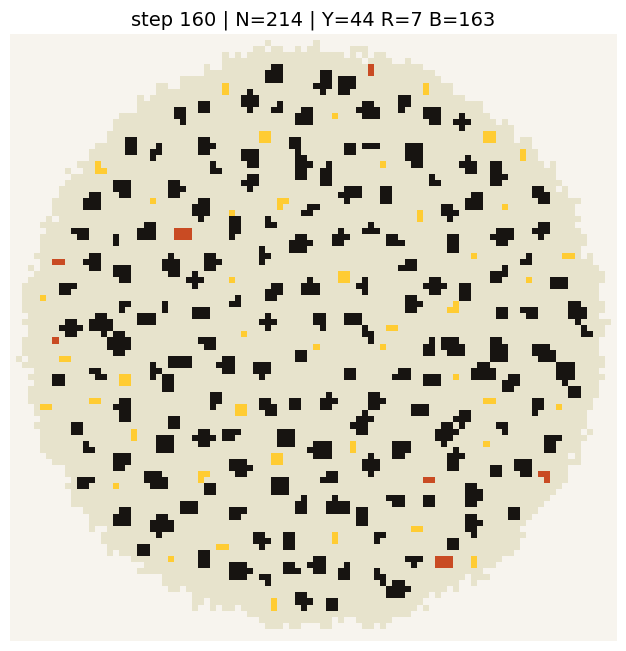

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/final_frame_preview.png


In [ ]:
# %% Cell 4: Preview final frame
figsize = (6.4, 6.4)
dpi = 220
preview_title = (
    f"step {final_step} | N={final_frame.pigment_count} | "
    f"Y={final_frame.yellow_count} R={final_frame.red_count} B={final_frame.black_count}"
)
supfig1_preview_path = REPORT_DIR / "SupFig1_final_frame_preview.png"

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)

state_grid = final_frame.skin.copy()
score_grid = np.full(final_frame.skin.shape, -np.inf, dtype=float)
priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}

grid_size = final_frame.skin.shape[0]
for pigment in final_frame.pigments:
    stage = pigment.stage(params)
    major, minor = pigment_display_size(pigment, params)
    half_h = max(1, int(math.ceil(major * 0.75)))
    half_w = max(1, int(math.ceil(major * 0.75)))
    rr_center = pigment.pos[0]
    cc_center = pigment.pos[1]
    angle = math.radians(pigment.angle)
    cos_a = math.cos(angle)
    sin_a = math.sin(angle)

    rows = []
    cols = []
    for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
        if rr < 0 or rr >= grid_size:
            continue
        for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
            if cc < 0 or cc >= grid_size:
                continue
            dy = rr - rr_center
            dx = cc - cc_center
            x_rot = cos_a * dx + sin_a * dy
            y_rot = -sin_a * dx + cos_a * dy
            value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
            if value <= 1.0:
                rows.append(rr)
                cols.append(cc)

    if not rows:
        rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
        cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]

    rows = np.asarray(rows, dtype=int)
    cols = np.asarray(cols, dtype=int)
    dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
    local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age

    for rr, cc, score in zip(rows, cols, local_score):
        if final_frame.skin[rr, cc] != SKIN:
            continue
        if score > score_grid[rr, cc]:
            state_grid[rr, cc] = stage
            score_grid[rr, cc] = score

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(preview_title, pad=7)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.savefig(supfig1_preview_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(supfig1_preview_path)


In [5]:
# %% Optional: Save GIF if needed
frame_stride = params["frame_stride"]
gif_duration_ms = params["gif_duration_ms"]
gif_path = RESULTS_DIR / "01_intercalated_development.gif"

frame_steps = list(range(0, final_step + 1, frame_stride))
if frame_steps[-1] != final_step:
    frame_steps.append(final_step)

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)

with TemporaryDirectory() as tmp_dir_name:
    tmp_dir = Path(tmp_dir_name)
    frame_paths = []
    for step in frame_steps:
        frame = timeline[step]
        state_grid = frame.skin.copy()
        score_grid = np.full(frame.skin.shape, -np.inf, dtype=float)
        priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}
        grid_size = frame.skin.shape[0]

        for pigment in frame.pigments:
            stage = pigment.stage(params)
            major, minor = pigment_display_size(pigment, params)
            half_h = max(1, int(math.ceil(major * 0.75)))
            half_w = max(1, int(math.ceil(major * 0.75)))
            rr_center = pigment.pos[0]
            cc_center = pigment.pos[1]
            angle = math.radians(pigment.angle)
            cos_a = math.cos(angle)
            sin_a = math.sin(angle)
            rows = []
            cols = []
            for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
                if rr < 0 or rr >= grid_size:
                    continue
                for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
                    if cc < 0 or cc >= grid_size:
                        continue
                    dy = rr - rr_center
                    dx = cc - cc_center
                    x_rot = cos_a * dx + sin_a * dy
                    y_rot = -sin_a * dx + cos_a * dy
                    value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
                    if value <= 1.0:
                        rows.append(rr)
                        cols.append(cc)
            if not rows:
                rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
                cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]
            rows = np.asarray(rows, dtype=int)
            cols = np.asarray(cols, dtype=int)
            dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
            local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age
            for rr, cc, score in zip(rows, cols, local_score):
                if frame.skin[rr, cc] != SKIN:
                    continue
                if score > score_grid[rr, cc]:
                    state_grid[rr, cc] = stage
                    score_grid[rr, cc] = score

        fig, ax = plt.subplots(figsize=(6.2, 6.2), constrained_layout=True)
        ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(
            f"step {frame.step} | skin={frame.skin_area} | pigments={frame.pigment_count} | "
            f"Y={frame.yellow_count} R={frame.red_count} B={frame.black_count}",
            pad=7,
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        frame_path = tmp_dir / f"frame_{step:04d}.png"
        fig.savefig(frame_path, dpi=180)
        plt.close(fig)
        frame_paths.append(frame_path)

    images = []
    for frame_path in frame_paths:
        with Image.open(frame_path) as img:
            images.append(img.convert("P", palette=Image.ADAPTIVE))
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=gif_duration_ms,
        loop=0,
        disposal=2,
    )

print(gif_path)


/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/01_intercalated_development.gif


In [6]:
# %% Cell 5: Run matched controls
self_summary = summarize_result({
    "mode": "self",
    "seed": params["seed"],
    "final_frame": final_frame,
    "birth_rate_scale": 1.0,
    "switches": {
        "use_repulsion": True,
        "use_gap_birth": True,
        "use_growth_displacement": True,
    },
})

random_dev_result = run_random_development_matched(
    params,
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)
random_mask_result = run_random_mask(
    final_frame, 
    target_N=final_frame.pigment_count, 
    seed=params["seed"] + 400
)

random_dev_summary = summarize_result(random_dev_result)
random_mask_summary = summarize_result(random_mask_result)
summary_df = pd.DataFrame([self_summary, random_dev_summary, random_mask_summary])

print(summary_df[["model", "N", "CV_NND", "yellow_count", "red_count", "black_count"]])
print(f"random-development birth_rate_scale = {random_dev_result['birth_rate_scale']:.6f}")

summary_df


                        model    N    CV_NND  yellow_count  red_count  \
0                        self  214  0.163522            44          7   
1  random_development_matched  210  0.482311            65          3   
2                 random_mask  214  0.489510            44          7   

   black_count  
0          163  
1          142  
2          163  
random-development birth_rate_scale = 0.001760


,model,seed,N,mean_NND,std_NND,CV_NND,yellow_count,red_count,black_count,yellow_fraction,red_fraction,black_fraction,use_repulsion,use_gap_birth,use_growth_displacement,calibrated_birth_rate,knn_distance,knn_distance_std,short_range_pair_density,first_pair_density_peak_distance
0,self,7,214,4.355265,0.712181,0.163522,44,7,163,0.205607,0.032710,0.761682,True,True,True,1.00000,NaN,NaN,NaN,NaN
1,random_development_matched,7,210,2.705408,1.304849,0.482311,65,3,142,0.309524,0.014286,0.676190,False,False,True,0.00176,NaN,NaN,NaN,NaN
2,random_mask,407,214,3.056024,1.495954,0.489510,44,7,163,0.205607,0.032710,0.761682,False,False,False,NaN,NaN,NaN,NaN,NaN


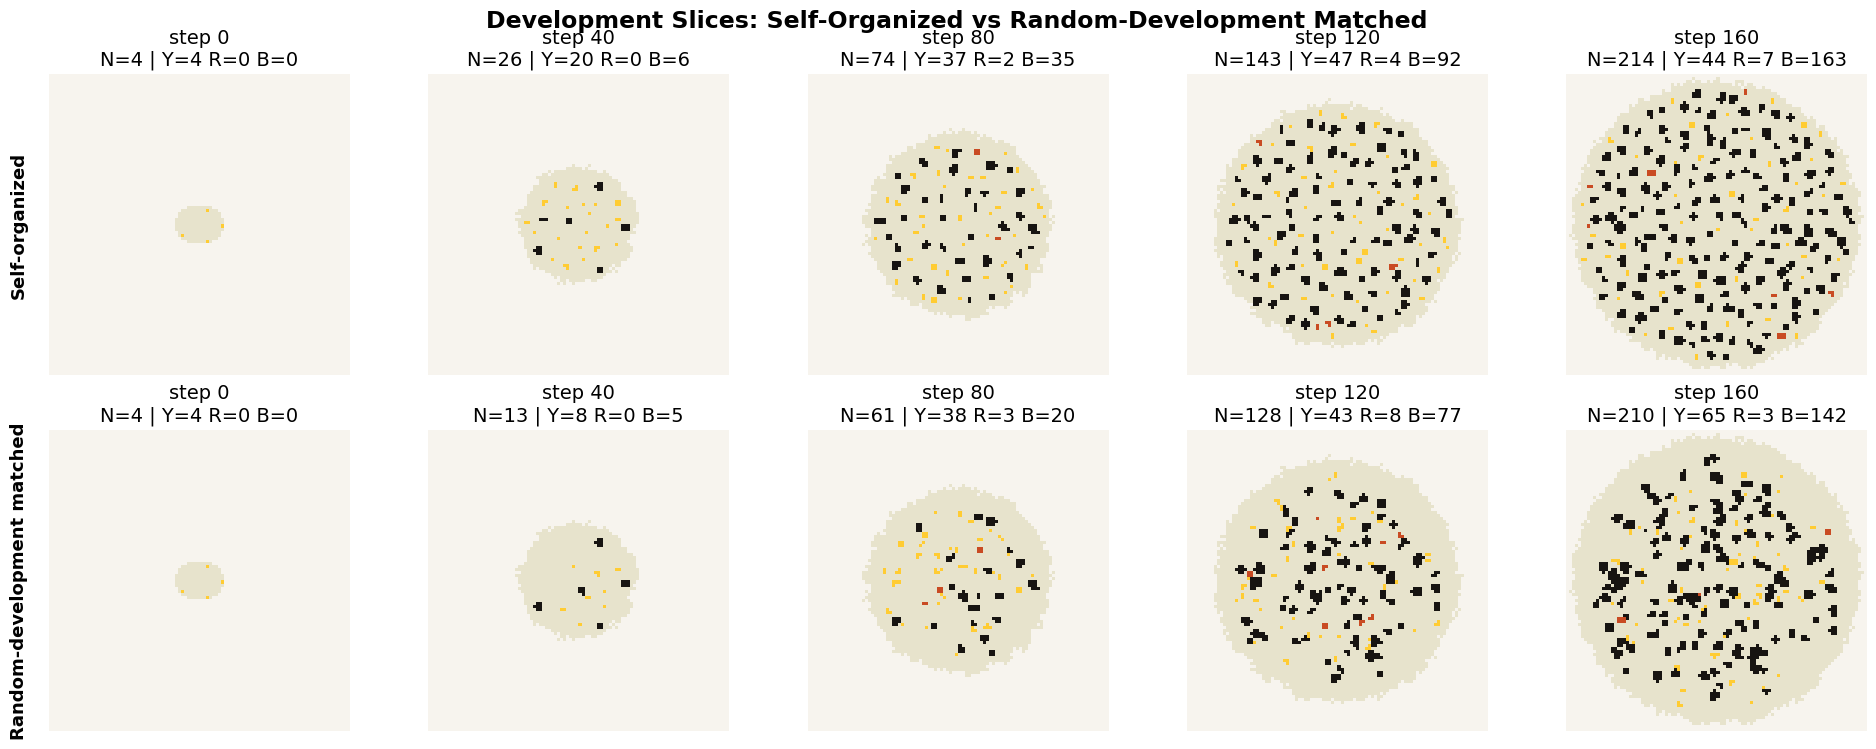

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig1_development_slices_self_vs_random.png


In [7]:
# %% Cell 6: Fig1 development slices
fig1_path = REPORT_DIR / "Fig1_development_slices_self_vs_random.png"
figsize = (19.0, 7.2)
dpi = 220

fig_steps = comparison_steps.copy()
while len(fig_steps) < 5:
    fig_steps.append(min(comparison_step, fig_steps[-1] + 1 if fig_steps else 0))
fig_steps = fig_steps[:5]
self_steps = fig_steps
random_steps = fig_steps

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)
priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}

fig, axes = plt.subplots(2, 5, figsize=figsize, constrained_layout=True)
for row_idx, (row_label, row_timeline, row_steps) in enumerate([
    ("Self-organized", timeline, self_steps),
    ("Random-development matched", random_dev_result["timeline"], random_steps),
]):
    for col_idx, step in enumerate(row_steps):
        frame = row_timeline[step]
        state_grid = frame.skin.copy()
        score_grid = np.full(frame.skin.shape, -np.inf, dtype=float)
        grid_size = frame.skin.shape[0]
        for pigment in frame.pigments:
            stage = pigment.stage(params)
            major, minor = pigment_display_size(pigment, params)
            half_h = max(1, int(math.ceil(major * 0.75)))
            half_w = max(1, int(math.ceil(major * 0.75)))
            rr_center = pigment.pos[0]
            cc_center = pigment.pos[1]
            angle = math.radians(pigment.angle)
            cos_a = math.cos(angle)
            sin_a = math.sin(angle)
            rows = []
            cols = []
            for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
                if rr < 0 or rr >= grid_size:
                    continue
                for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
                    if cc < 0 or cc >= grid_size:
                        continue
                    dy = rr - rr_center
                    dx = cc - cc_center
                    x_rot = cos_a * dx + sin_a * dy
                    y_rot = -sin_a * dx + cos_a * dy
                    value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
                    if value <= 1.0:
                        rows.append(rr)
                        cols.append(cc)
            if not rows:
                rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
                cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]
            rows = np.asarray(rows, dtype=int)
            cols = np.asarray(cols, dtype=int)
            dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
            local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age
            for rr, cc, score in zip(rows, cols, local_score):
                if frame.skin[rr, cc] != SKIN:
                    continue
                if score > score_grid[rr, cc]:
                    state_grid[rr, cc] = stage
                    score_grid[rr, cc] = score
        ax = axes[row_idx, col_idx]
        ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(
            f"step {step}\nN={frame.pigment_count} | Y={frame.yellow_count} R={frame.red_count} B={frame.black_count}",
            pad=7,
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        if col_idx == 0:
            ax.text(-0.10, 0.5, row_label, transform=ax.transAxes, rotation=90, va="center", ha="center", fontsize=13, fontweight="bold")

fig.suptitle("Development Slices: Self-Organized vs Random-Development Matched", y=1.02, fontsize=17, fontweight="bold")
fig.savefig(fig1_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig1_path)


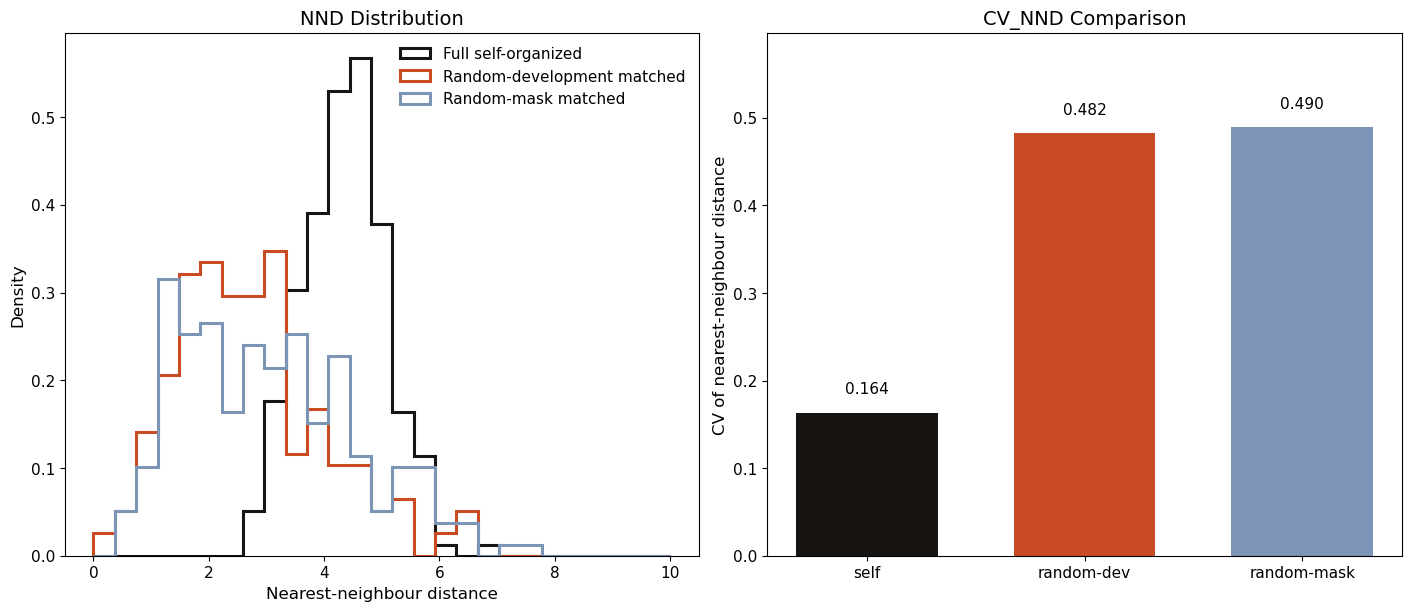

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig2_nnd_distribution_and_cv.png
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Table1_random_vs_self_summary.csv


In [8]:
# %% Cell 7: Fig2 NND distribution and CV
fig2_path = REPORT_DIR / "Fig2_nnd_distribution_and_cv.png"
summary_csv_path = REPORT_DIR / "Table1_random_vs_self_summary.csv"
figsize = (14, 6)
dpi = 220

summary_df.to_csv(summary_csv_path, index=False)

nnd_map = {
    "self": nearest_neighbor_distances(pigment_points(final_frame)),
    "random_development_matched": nearest_neighbor_distances(pigment_points(random_dev_result["final_frame"])),
    "random_mask": nearest_neighbor_distances(pigment_points(random_mask_result["final_frame"])),
}
labels = {
    "self": MODE_LABELS["self"],
    "random_development_matched": MODE_LABELS["random_development_matched"],
    "random_mask": MODE_LABELS["random_mask"],
}
colors = {
    "self": MODE_COLORS["self"],
    "random_development_matched": MODE_COLORS["random_development_matched"],
    "random_mask": MODE_COLORS["random_mask"],
}
bins = np.linspace(0.0, 10.0, 28)
bar_order = ["self", "random_development_matched", "random_mask"]
bar_labels = ["self", "random-dev", "random-mask"]
bar_colors = [colors[key] for key in bar_order]

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
for model, values in nnd_map.items():
    axes[0].hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.2,
        color=colors[model],
        label=labels[model],
    )
axes[0].set_xlabel("Nearest-neighbour distance")
axes[0].set_ylabel("Density")
axes[0].set_title("NND Distribution")
axes[0].legend(frameon=False, loc="upper right")

cv_values = summary_df.set_index("model").loc[bar_order, "CV_NND"].to_numpy()
axes[1].bar(bar_labels, cv_values, color=bar_colors, width=0.65)
axes[1].set_ylabel("CV of nearest-neighbour distance")
axes[1].set_title("CV_NND Comparison")
y_top = max(cv_values) * 1.22 if len(cv_values) else 1.0
axes[1].set_ylim(0.0, y_top)
for idx, value in enumerate(cv_values):
    axes[1].text(idx, value + 0.03 * y_top, f"{value:.3f}", ha="center", va="bottom", fontsize=11)

fig.savefig(fig2_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig2_path)
print(summary_csv_path)


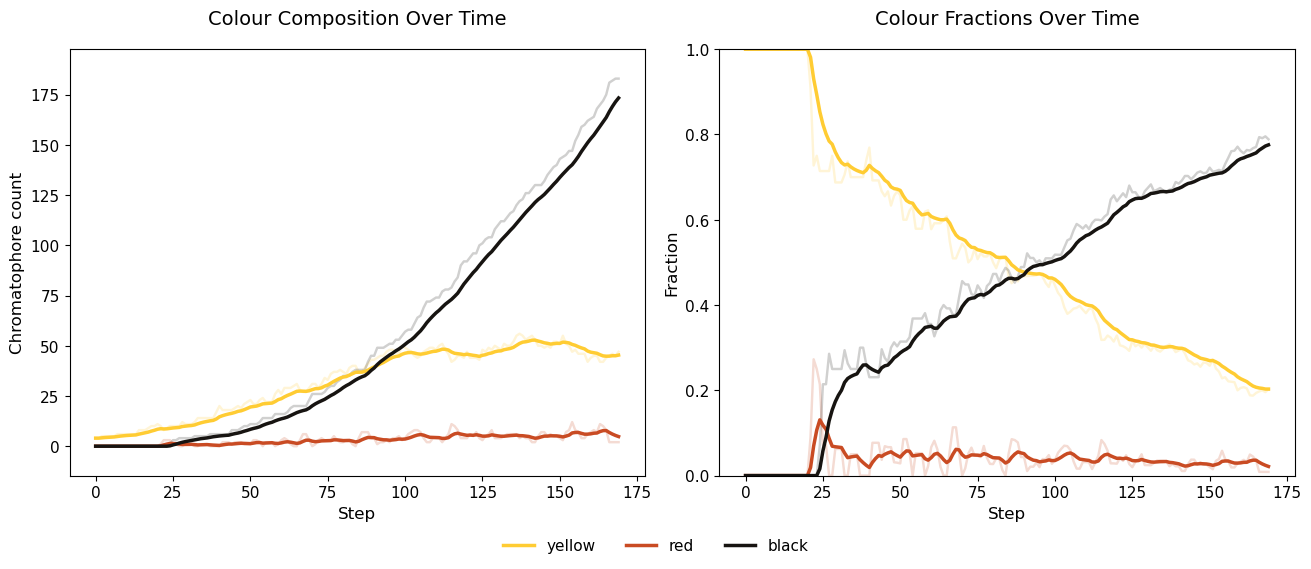

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig3_color_composition_over_time.png
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Table2_metrics_over_time.csv


In [ ]:
# %% Cell 8: Fig3 color composition over time
fig3_path = REPORT_DIR / "Fig3_color_composition_over_time.png"
metrics_csv_path = REPORT_DIR / "Table2_metrics_over_time.csv"
figsize = (13.0, 5.2)
dpi = 220

# Smoothing parameter
smooth_span = 11

metrics_df = timeline_to_dataframe(timeline)
metrics_df.to_csv(metrics_csv_path, index=False)

count_cols = ["yellow_count", "red_count", "black_count"]

# Smoothed counts
smooth_counts = (
    metrics_df[count_cols]
    .ewm(span=smooth_span, adjust=False)
    .mean()
)

# Fractions from smoothed counts
smooth_total = smooth_counts.sum(axis=1).replace(0, np.nan)
smooth_fractions = smooth_counts.div(smooth_total, axis=0).fillna(0.0)

# Raw fractions
raw_fractions = (
    metrics_df[count_cols]
    .div(metrics_df["pigment_count"].replace(0, np.nan), axis=0)
    .fillna(0.0)
)

line_colors = {"yellow": "#ffcc33", "red": "#c94b23", "black": "#171411"}
smooth_line_widths = {"yellow": 2.5, "red": 2.5, "black": 2.5}
raw_line_widths = {"yellow": 1.75, "red": 1.75, "black": 1.75}
raw_alpha = 0.2

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

# -------------------------
# Left panel: counts
# raw lines
axes[0].plot(
    metrics_df["step"], metrics_df["yellow_count"],
    color=line_colors["yellow"], linewidth=raw_line_widths["yellow"], alpha=raw_alpha
)
axes[0].plot(
    metrics_df["step"], metrics_df["red_count"],
    color=line_colors["red"], linewidth=raw_line_widths["red"], alpha=raw_alpha
)
axes[0].plot(
    metrics_df["step"], metrics_df["black_count"],
    color=line_colors["black"], linewidth=raw_line_widths["black"], alpha=raw_alpha
)

# smoothed lines
axes[0].plot(
    metrics_df["step"], smooth_counts["yellow_count"],
    color=line_colors["yellow"], linewidth=smooth_line_widths["yellow"], label="yellow"
)
axes[0].plot(
    metrics_df["step"], smooth_counts["red_count"],
    color=line_colors["red"], linewidth=smooth_line_widths["red"], label="red"
)
axes[0].plot(
    metrics_df["step"], smooth_counts["black_count"],
    color=line_colors["black"], linewidth=smooth_line_widths["black"], label="black"
)

axes[0].set_xlabel("Step")
axes[0].set_ylabel("Chromatophore count")
axes[0].set_title("Colour Composition Over Time", pad=18)
axes[0].margins(y=0.08)

# -------------------------
# Right panel: fractions
# raw lines
axes[1].plot(
    metrics_df["step"], raw_fractions["yellow_count"],
    color=line_colors["yellow"], linewidth=raw_line_widths["yellow"], alpha=raw_alpha
)
axes[1].plot(
    metrics_df["step"], raw_fractions["red_count"],
    color=line_colors["red"], linewidth=raw_line_widths["red"], alpha=raw_alpha
)
axes[1].plot(
    metrics_df["step"], raw_fractions["black_count"],
    color=line_colors["black"], linewidth=raw_line_widths["black"], alpha=raw_alpha
)

# smoothed lines
axes[1].plot(
    metrics_df["step"], smooth_fractions["yellow_count"],
    color=line_colors["yellow"], linewidth=smooth_line_widths["yellow"], label="yellow"
)
axes[1].plot(
    metrics_df["step"], smooth_fractions["red_count"],
    color=line_colors["red"], linewidth=smooth_line_widths["red"], label="red"
)
axes[1].plot(
    metrics_df["step"], smooth_fractions["black_count"],
    color=line_colors["black"], linewidth=smooth_line_widths["black"], label="black"
)

axes[1].set_xlabel("Step")
axes[1].set_ylabel("Fraction")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Colour Fractions Over Time", pad=18)
axes[1].margins(y=0.05)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    frameon=False, ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08)
)

fig.savefig(fig3_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig3_path)
print(metrics_csv_path)

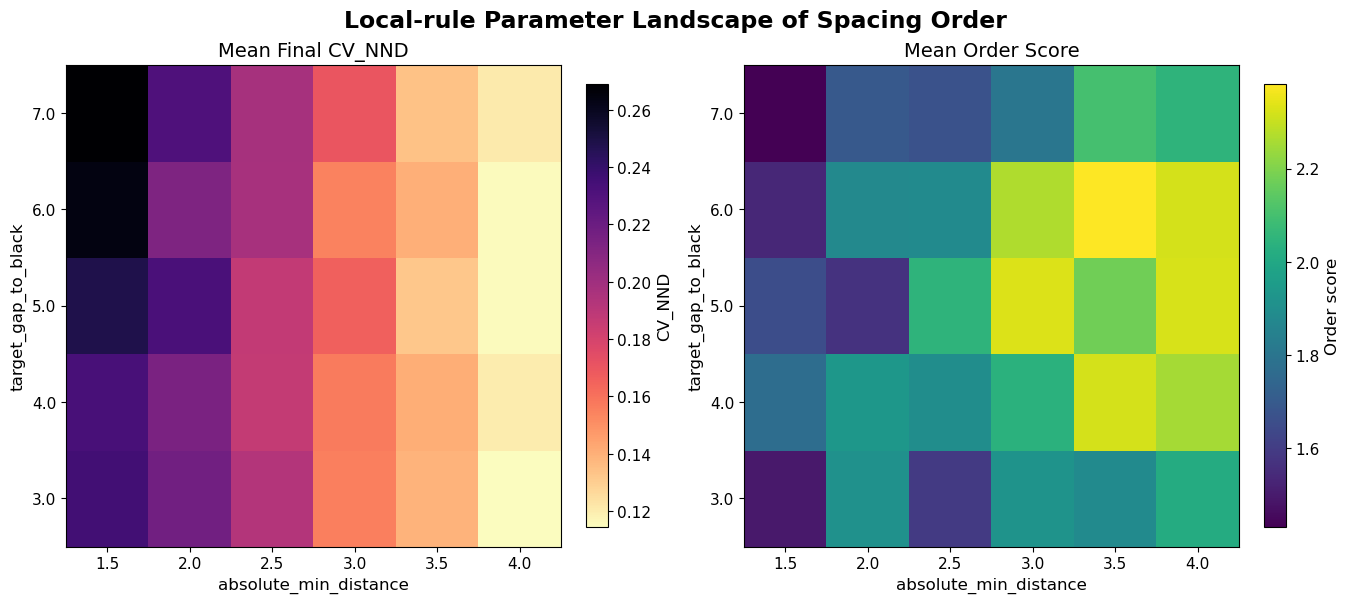

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/SupFig1_parameter_phase_heatmap.png
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/SupTable1_parameter_scan.csv


In [ ]:
# %% Cell 9: SupFig1 parameter heatmap
supfig2_path = REPORT_DIR / "SupFig2_parameter_phase_heatmap.png"
suptable1_csv_path = REPORT_DIR / "SupTable1_parameter_scan.csv"
figsize = (13.4, 5.6)
dpi = 220

absolute_min_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
target_gap_values = [3.0, 4.0, 5.0, 6.0, 7.0]
n_replicates = 3
replicate_seeds = [params["seed"] + 10 * i for i in range(n_replicates)]

scan_df = scan_parameter_landscape(
    params,
    absolute_min_distance_values=absolute_min_values,
    target_gap_values=target_gap_values,
    seeds=replicate_seeds,
)
scan_df.to_csv(suptable1_csv_path, index=False)

cv_grid = (
    scan_df.groupby(["target_gap_to_black", "absolute_min_distance"])["final_cv_nnd"]
    .mean()
    .unstack()
    .reindex(index=target_gap_values, columns=absolute_min_values)
)
order_grid = (
    scan_df.groupby(["target_gap_to_black", "absolute_min_distance"])["order_score"]
    .mean()
    .unstack()
    .reindex(index=target_gap_values, columns=absolute_min_values)
)

fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
image1 = axes[0].imshow(cv_grid.to_numpy(), origin="lower", aspect="auto", cmap="magma_r")
axes[0].set_title("Mean Final CV_NND")
axes[0].set_xlabel("absolute_min_distance")
axes[0].set_ylabel("target_gap_to_black")
axes[0].set_xticks(range(len(absolute_min_values)), [f"{value:.1f}" for value in absolute_min_values])
axes[0].set_yticks(range(len(target_gap_values)), [f"{value:.1f}" for value in target_gap_values])
cbar1 = fig.colorbar(image1, ax=axes[0], shrink=0.92)
cbar1.set_label("CV_NND")

image2 = axes[1].imshow(order_grid.to_numpy(), origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("Mean Order Score")
axes[1].set_xlabel("absolute_min_distance")
axes[1].set_ylabel("target_gap_to_black")
axes[1].set_xticks(range(len(absolute_min_values)), [f"{value:.1f}" for value in absolute_min_values])
axes[1].set_yticks(range(len(target_gap_values)), [f"{value:.1f}" for value in target_gap_values])
cbar2 = fig.colorbar(image2, ax=axes[1], shrink=0.92)
cbar2.set_label("Order score")

fig.suptitle("Local-rule Parameter Landscape of Spacing Order", y=1.05, fontsize=17, fontweight="bold")
fig.savefig(supfig2_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(supfig2_path)
print(suptable1_csv_path)


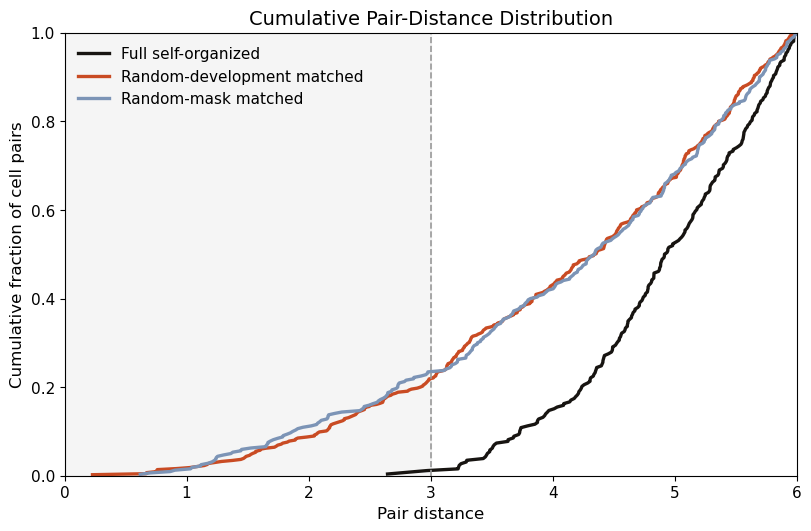

self fraction of pairs <= 3.0: 0.000132
random-development fraction of pairs <= 3.0: 0.004329
random-mask fraction of pairs <= 3.0: 0.003291
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig5_pair_distance_cdf.png


In [ ]:
# %% Cell 10: Fig5 pair correlation
fig4_path = REPORT_DIR / "Fig4_pair_distance_cdf.png"
figsize = (8.0, 5.2)
dpi = 220
r_max = 6.0
short_cutoff = 3.0


def pair_distances(points):
    """Return all unordered pairwise distances among pigment points."""
    points = np.asarray(points, dtype=float)
    if len(points) < 2:
        return np.array([], dtype=float)

    diff = points[:, None, :] - points[None, :, :]
    dist = np.sqrt((diff ** 2).sum(axis=-1))
    iu = np.triu_indices(len(points), k=1)
    return dist[iu]


def ecdf(distances, r_max=None):
    """Empirical cumulative distribution function."""
    d = np.sort(np.asarray(distances, dtype=float))
    if r_max is not None:
        d = d[d <= r_max]
    if len(d) == 0:
        return np.array([]), np.array([])
    y = np.arange(1, len(d) + 1) / len(d)
    return d, y


def cdf_at_cutoff(distances, cutoff):
    distances = np.asarray(distances, dtype=float)
    if len(distances) == 0:
        return np.nan
    return float(np.mean(distances <= cutoff))


self_dist = pair_distances(pigment_points(final_frame))
rand_dev_dist = pair_distances(pigment_points(random_dev_result["final_frame"]))
mask_dist = pair_distances(pigment_points(random_mask_result["final_frame"]))

self_x, self_y = ecdf(self_dist, r_max=r_max)
rand_dev_x, rand_dev_y = ecdf(rand_dev_dist, r_max=r_max)
mask_x, mask_y = ecdf(mask_dist, r_max=r_max)

self_short_cdf = cdf_at_cutoff(self_dist, short_cutoff)
rand_dev_short_cdf = cdf_at_cutoff(rand_dev_dist, short_cutoff)
mask_short_cdf = cdf_at_cutoff(mask_dist, short_cutoff)

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

ax.plot(
    self_x, self_y,
    color=MODE_COLORS["self"],
    linewidth=2.4,
    label=MODE_LABELS["self"],
)
ax.plot(
    rand_dev_x, rand_dev_y,
    color=MODE_COLORS["random_development_matched"],
    linewidth=2.4,
    label=MODE_LABELS["random_development_matched"],
)
ax.plot(
    mask_x, mask_y,
    color=MODE_COLORS["random_mask"],
    linewidth=2.4,
    label=MODE_LABELS["random_mask"],
)

ax.axvspan(0.0, short_cutoff, color="#d9d9d9", alpha=0.25)
ax.axvline(short_cutoff, color="#999999", linestyle="--", linewidth=1.2)

ax.set_xlim(0, r_max)
ax.set_ylim(0, 1.0)
ax.set_xlabel("Pair distance")
ax.set_ylabel("Cumulative fraction of cell pairs")
ax.set_title("Cumulative Pair-Distance Distribution")
ax.legend(frameon=False)

fig.savefig(fig4_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(f"self fraction of pairs <= {short_cutoff}: {self_short_cdf:.6f}")
print(f"random-development fraction of pairs <= {short_cutoff}: {rand_dev_short_cdf:.6f}")
print(f"random-mask fraction of pairs <= {short_cutoff}: {mask_short_cdf:.6f}")
print(fig4_path)

In [12]:
# %% Cell 11: Ablation runs
ablation_csv_path = REPORT_DIR / "Table3_ablation_summary.csv"

full_self_result = {
    "mode": "self",
    "seed": params["seed"],
    "timeline": timeline,
    "final_step": final_step,
    "final_frame": final_frame,
    "birth_rate_scale": 1.0,
    "switches": {
        "use_repulsion": True,
        "use_gap_birth": True,
        "use_growth_displacement": True,
    },
    "params": params,
}
no_repulsion_result = run_ablation(
    params,
    mode="no_repulsion",
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)
no_gap_birth_result = run_ablation(
    params,
    mode="no_gap_birth",
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)
no_growth_displacement_result = run_ablation(
    params,
    mode="no_growth_displacement",
    target_N=final_frame.pigment_count,
    seed=params["seed"],
    comparison_step=comparison_step,
)

ablation_results = [
    full_self_result,
    no_repulsion_result,
    no_gap_birth_result,
    no_growth_displacement_result,
    random_dev_result,
    random_mask_result,
]

ablation_summary_df = pd.DataFrame([summarize_result(result) for result in ablation_results])
# TODO: fill pair-density summary columns after computing mode-specific pair-density
# curves for each ablation final frame.
ablation_summary_df.to_csv(ablation_csv_path, index=False)

print(ablation_summary_df[["model", "N", "CV_NND", "yellow_count", "red_count", "black_count"]])
print(ablation_csv_path)

ablation_summary_df


                        model    N    CV_NND  yellow_count  red_count  \
0                        self  214  0.163522            44          7   
1                no_repulsion  216  0.470666            70          3   
2                no_gap_birth  196  0.198911            47          1   
3      no_growth_displacement  195  0.213881            49          4   
4  random_development_matched  210  0.482311            65          3   
5                 random_mask  214  0.489510            44          7   

   black_count  
0          163  
1          143  
2          148  
3          142  
4          142  
5          163  
/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Table3_ablation_summary.csv


,model,seed,N,mean_NND,std_NND,CV_NND,yellow_count,red_count,black_count,yellow_fraction,red_fraction,black_fraction,use_repulsion,use_gap_birth,use_growth_displacement,calibrated_birth_rate,knn_distance,knn_distance_std,short_range_pair_density,first_pair_density_peak_distance
0,self,7,214,4.355265,0.712181,0.163522,44,7,163,0.205607,0.032710,0.761682,True,True,True,1.00000,NaN,NaN,NaN,NaN
1,no_repulsion,7,216,2.938454,1.383029,0.470666,70,3,143,0.324074,0.013889,0.662037,False,True,True,0.00250,NaN,NaN,NaN,NaN
2,no_gap_birth,7,196,4.240635,0.843510,0.198911,47,1,148,0.239796,0.005102,0.755102,True,False,True,0.27675,NaN,NaN,NaN,NaN
3,no_growth_displacement,7,195,3.825974,0.818303,0.213881,49,4,142,0.251282,0.020513,0.728205,True,True,False,1.00000,NaN,NaN,NaN,NaN
4,random_development_matched,7,210,2.705408,1.304849,0.482311,65,3,142,0.309524,0.014286,0.676190,False,False,True,0.00176,NaN,NaN,NaN,NaN
5,random_mask,407,214,3.056024,1.495954,0.489510,44,7,163,0.205607,0.032710,0.761682,False,False,False,NaN,NaN,NaN,NaN,NaN


                        model    CV_NND  knn_distance  knn_distance_std  \
0                        self  0.163522      4.355265          0.712181   
1                no_repulsion  0.470666      2.938454          1.383029   
2                no_gap_birth  0.198911      4.240635          0.843510   
3      no_growth_displacement  0.213881      3.825974          0.818303   
4  random_development_matched  0.482311      2.705408          1.304849   
5                 random_mask  0.489510      3.056024          1.495954   

   first_pair_density_peak_distance  short_range_pair_density  
0                               5.1                  0.000275  
1                               0.9                  0.014726  
2                               6.3                  0.000501  
3                               4.5                  0.001511  
4                               2.7                  0.013995  
5                               2.1                  0.010454  


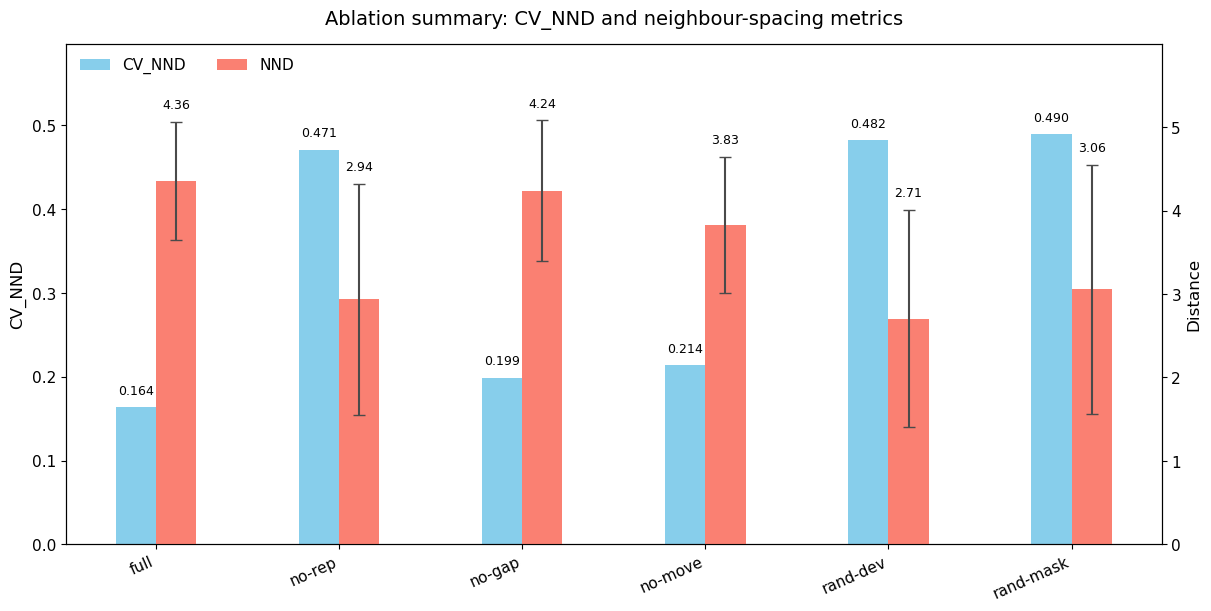

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig5_ablation_summary.png


In [34]:
# %% Cell 12: Fig6 ablation summary
fig5_path = REPORT_DIR / "Fig5_ablation_summary.png"
figsize = (12, 6)
dpi = 220
pair_bins = np.linspace(0.0, 18.0, 31)

order = ["self", "no_repulsion", "no_gap_birth", "no_growth_displacement", "random_development_matched", "random_mask"]
labels = ["full", "no-rep", "no-gap", "no-move", "rand-dev", "rand-mask"]
summary_index_labels = [MODE_LABELS[key] for key in order]

k_neighbor = 1

pair_metric_records = []
for result in ablation_results:
    frame = result["final_frame"]
    points = pigment_points(frame)
    centers, density = pair_correlation_like(points, bins=pair_bins)
    pair_metric_records.append(
        {
            "model": result["mode"],
            "knn_distance": mean_knn_distance(points, k=k_neighbor),
            "knn_distance_std": std_knn_distance(points, k=k_neighbor),
            "short_range_pair_density": short_range_pair_density(centers, density, cutoff=3.0),
            "first_pair_density_peak_distance": first_pair_density_peak_distance(
                centers, density, max_distance=10.0, smooth_window=3, min_rel_height=0.5
            ),
        }
    )

pair_metrics_df = pd.DataFrame(pair_metric_records).set_index("model").loc[order]
ablation_summary_df = ablation_summary_df.set_index("model")
for col in [
    "knn_distance",
    "knn_distance_std",
    "short_range_pair_density",
    "first_pair_density_peak_distance",
]:
    ablation_summary_df.loc[order, col] = pair_metrics_df[col]
ablation_summary_df = ablation_summary_df.reset_index()
ablation_summary_df.to_csv(ablation_csv_path, index=False)

print(ablation_summary_df[["model", "CV_NND", "knn_distance", "knn_distance_std", "first_pair_density_peak_distance", "short_range_pair_density"]])

summary_indexed = ablation_summary_df.set_index("model").loc[order]
x = np.arange(len(order), dtype=float)
width = 0.22

fig, ax_left = plt.subplots(figsize=figsize, constrained_layout=True)
ax_right = ax_left.twinx()

cv_color = "skyblue"
pair_color = "salmon"
peak_color = "lightgreen"

cv_values = summary_indexed["CV_NND"].to_numpy()
knn_values = summary_indexed["knn_distance"].to_numpy()
knn_errors = summary_indexed["knn_distance_std"].to_numpy()
# peak_values = summary_indexed["first_pair_density_peak_distance"].to_numpy()

bars_cv = ax_left.bar(x - width / 2, cv_values, width=width, color=cv_color, label="CV_NND")
bars_pair = ax_right.bar(
    x + width / 2,
    knn_values,
    width=width,
    color=pair_color,
    label=f"knn_distance (k={k_neighbor})",
    yerr=knn_errors,
    capsize=4,
    ecolor="#4a4a4a",
)
# bars_peak = ax_right.bar(x + width, peak_values, width=width, color=peak_color, label="first_peak_pair_distance")

ax_left.set_xticks(x)
ax_left.set_xticklabels(labels, rotation=24, ha="right")
ax_left.set_ylabel("CV_NND") 
ax_right.set_ylabel("Distance")
ax_left.set_title("Ablation summary: CV_NND and neighbour-spacing metrics", pad=14)

left_ymax = np.nanmax(cv_values) if np.any(~np.isnan(cv_values)) else 1.0
# right_candidates = np.concatenate([knn_values, peak_values, knn_values + np.nan_to_num(knn_errors, nan=0.0)])
right_candidates = np.concatenate([knn_values, knn_values + np.nan_to_num(knn_errors, nan=0.0)])
right_ymax = np.nanmax(right_candidates) if np.any(~np.isnan(right_candidates)) else 1.0
ax_left.set_ylim(0.0, left_ymax * 1.22 if left_ymax > 0 else 1.0)
ax_right.set_ylim(0.0, right_ymax * 1.18 if right_ymax > 0 else 1.0)

for bar, value in zip(bars_cv, cv_values):
    ax_left.text(bar.get_x() + bar.get_width() / 2.0, value + 0.02 * ax_left.get_ylim()[1], f"{value:.3f}", ha="center", va="bottom", fontsize=9)

for bar, value, error in zip(bars_pair, knn_values, knn_errors):
    err = 0.0 if np.isnan(error) else error
    ax_right.text(bar.get_x() + bar.get_width() / 2.0, value + err + 0.02 * ax_right.get_ylim()[1], f"{value:.2f}", ha="center", va="bottom", fontsize=9)

# for bar, value in zip(bars_peak, peak_values):
#     ax_right.text(bar.get_x() + bar.get_width() / 2.0, value + 0.02 * ax_right.get_ylim()[1], f"{value:.2f}", ha="center", va="bottom", fontsize=9)

# handles = [bars_cv, bars_pair, bars_peak]
handles = [bars_cv, bars_pair]
# legend_labels = ["CV_NND", f"knn_distance (k={k_neighbor})", "first_peak_pair_distance"]
legend_labels = ["CV_NND", "NND"]
ax_left.legend(handles, legend_labels, frameon=False, loc="upper left", ncol=3)

fig.savefig(fig5_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig5_path)


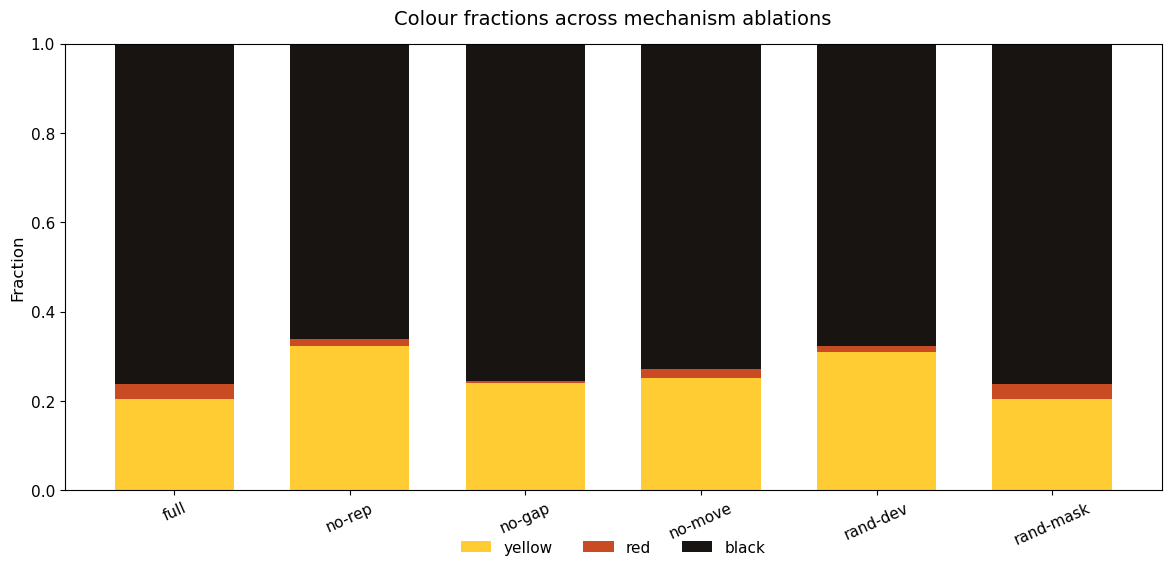

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/SupFig2_colour_fractions_ablation.png


In [ ]:
# %% Cell 13: SupFig2 colour fractions across ablations
supfig3_path = REPORT_DIR / "SupFig3_colour_fractions_ablation.png"
figsize = (11.6, 5.6)
dpi = 220

order = ["self", "no_repulsion", "no_gap_birth", "no_growth_displacement", "random_development_matched", "random_mask"]
labels = ["full", "no-rep", "no-gap", "no-move", "rand-dev", "rand-mask"]
ablation_summary_df = pd.read_csv(ablation_csv_path)
summary_indexed = ablation_summary_df.set_index("model").loc[order]

fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
bottoms = np.zeros(len(order))
for col, color, label in [
    ("yellow_fraction", "#ffcc33", "yellow"),
    ("red_fraction", "#c94b23", "red"),
    ("black_fraction", "#171411", "black"),
]:
    ax.bar(labels, summary_indexed[col], bottom=bottoms, color=color, width=0.68, label=label)
    bottoms += summary_indexed[col].to_numpy()

ax.set_ylim(0.0, 1.0)
ax.set_title("Colour fractions across mechanism ablations", pad=14)
ax.set_ylabel("Fraction")
ax.tick_params(axis="x", rotation=24)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)

fig.savefig(supfig3_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(supfig3_path)


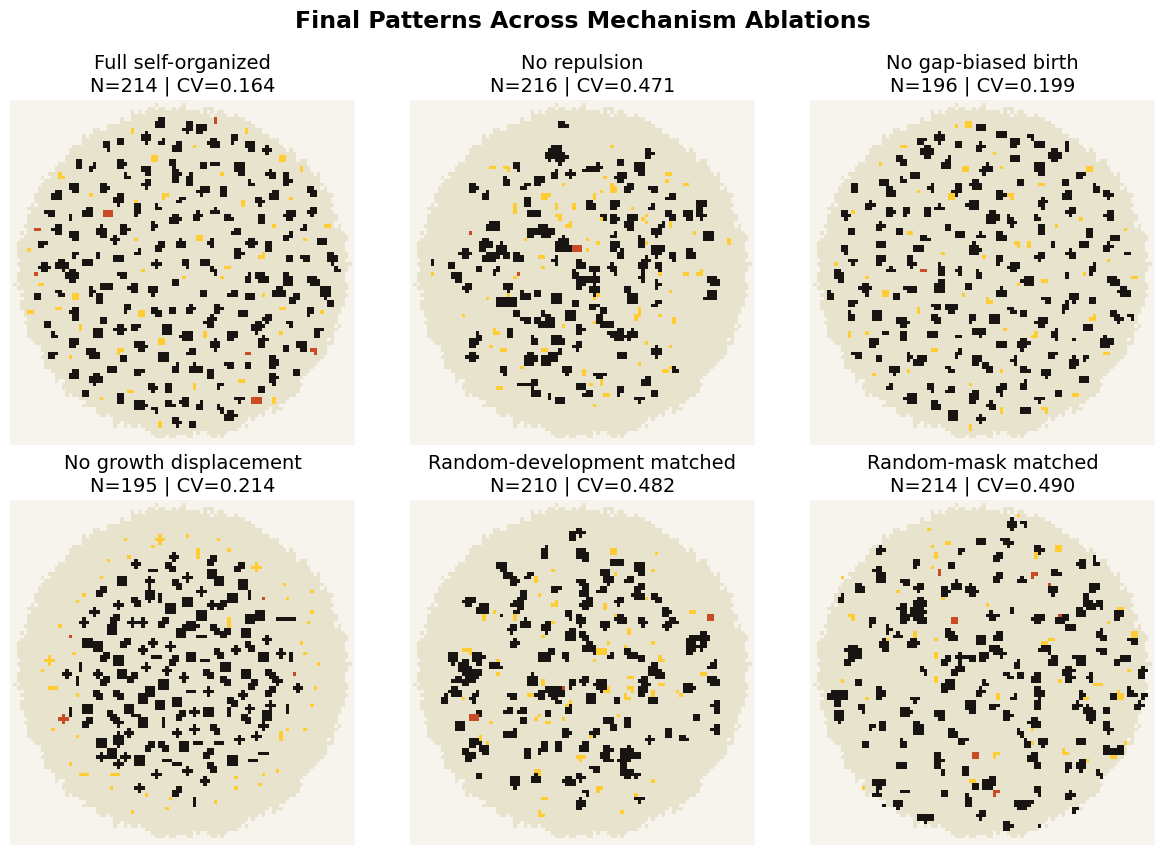

/Users/jastaron/wjc/Code/Python/demo/PKU-2026S-SysBio-Proj/results/Fig6_ablation_final_patterns.png


In [15]:
# %% Cell 14: Fig7 ablation final patterns
fig7_path = REPORT_DIR / "Fig6_ablation_final_patterns.png"
figsize = (12.0, 8.0)
dpi = 220

pattern_results = [
    full_self_result,
    no_repulsion_result,
    no_gap_birth_result,
    no_growth_displacement_result,
    random_dev_result,
    random_mask_result,
]

render_colors = ["#f7f4ee", "#e7e3cc", "#ffcc33", "#c94b23", "#171411"]
render_cmap = ListedColormap(render_colors)
render_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), render_cmap.N)
priority = {YELLOW: 1.0, RED: 2.0, BLACK: 3.0}

fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
for ax, result in zip(axes.flat, pattern_results):
    frame = result["final_frame"]
    state_grid = frame.skin.copy()
    score_grid = np.full(frame.skin.shape, -np.inf, dtype=float)
    grid_size = frame.skin.shape[0]
    for pigment in frame.pigments:
        stage = pigment.stage(params)
        major, minor = pigment_display_size(pigment, params)
        half_h = max(1, int(math.ceil(major * 0.75)))
        half_w = max(1, int(math.ceil(major * 0.75)))
        rr_center = pigment.pos[0]
        cc_center = pigment.pos[1]
        angle = math.radians(pigment.angle)
        cos_a = math.cos(angle)
        sin_a = math.sin(angle)
        rows = []
        cols = []
        for rr in range(int(math.floor(rr_center - half_h)), int(math.ceil(rr_center + half_h)) + 1):
            if rr < 0 or rr >= grid_size:
                continue
            for cc in range(int(math.floor(cc_center - half_w)), int(math.ceil(cc_center + half_w)) + 1):
                if cc < 0 or cc >= grid_size:
                    continue
                dy = rr - rr_center
                dx = cc - cc_center
                x_rot = cos_a * dx + sin_a * dy
                y_rot = -sin_a * dx + cos_a * dy
                value = (x_rot / max(major * 0.5, 1e-6)) ** 2 + (y_rot / max(minor * 0.5, 1e-6)) ** 2
                if value <= 1.0:
                    rows.append(rr)
                    cols.append(cc)
        if not rows:
            rows = [int(np.clip(round(rr_center), 0, grid_size - 1))]
            cols = [int(np.clip(round(cc_center), 0, grid_size - 1))]
        rows = np.asarray(rows, dtype=int)
        cols = np.asarray(cols, dtype=int)
        dist2 = (rows - pigment.pos[0]) ** 2 + (cols - pigment.pos[1]) ** 2
        local_score = priority[stage] * 100.0 - dist2 - 0.02 * pigment.age
        for rr, cc, score in zip(rows, cols, local_score):
            if frame.skin[rr, cc] != SKIN:
                continue
            if score > score_grid[rr, cc]:
                state_grid[rr, cc] = stage
                score_grid[rr, cc] = score
    ax.imshow(state_grid, cmap=render_cmap, norm=render_norm, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{MODE_LABELS[result['mode']]}\nN={frame.pigment_count} | CV={frame.nnd_cv:.3f}", pad=7)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Final Patterns Across Mechanism Ablations", y=1.05, fontsize=17, fontweight="bold")
fig.savefig(fig7_path, dpi=dpi, bbox_inches="tight")
plt.show()

print(fig7_path)
